In [54]:
# Notebook for work analyzing the validity of different structural predictions using different software tools. Also work on determining
# how helpful custom MSAs could be (particularly for multimers). 

In [55]:
from utils import * 
from files.pdb import PDBFile
import numpy as np
from typing import NamedTuple
from dataclasses import dataclass, asdict
import shutil 
from matplotlib.lines import Line2D
from datetime import datetime
import itertools
import os
import re

%load_ext autoreload 
%autoreload 2

date = datetime.now().strftime("%m_%d_%Y")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
level_1_conserved_cluster_ids = [8, 7, 0, 4, 5, 6, 1, 3, 2]
level_2_conserved_cluster_ids = [9, 12, 10, 13, 11]
level_3_conserved_cluster_ids = [18, 42, 33, 25, 17, 19, 20, 21, 50, 31, 40, 27, 34, 15, 14, 54, 24, 23, 41, 39, 57, 47, 48, 51, 45, 35, 49, 28, 62, 29]

In [57]:
# First want to evaluate the quality of the ColabFold structures. 
COLABFOLD_DIR = '../data/genes/colabfold/'
COLABFOLD_SCORES_PATTERN = r'*_scores_rank_001_alphafold2_ptm_model*.json'
COLABFOLD_MSA_PATTERN = r'*a3m'

plddts = dict()
ptms = dict()
msas = dict()

def get_msa_stats(msa:str):
    # It seems as though ColabFold embeds statistics from the MMseqs search in the FASTA headers. 
    fields = ['id', 'bit_score', 'identity', 'e_value', 'query_start', 'query_end', 'query_length', 'subject_start', 'subject_end', 'subject_length']
    headers = [line for line in msa.split('\n') if line.startswith('>')]

    df = pd.DataFrame([dict(zip(fields, header.split())) for header in headers])
    if len(df.columns) == 1:
        return {'msa':msa, 'msa_num_seqs':0}
    df = df[~df.bit_score.isnull()].copy()
    df['query_coverage'] = (df.query_end.astype(int) - df.query_start.astype(int)) / df.query_length.astype(int)

    info = dict()
    info['msa'] = msa
    info['msa_num_seqs'] = len(df)
    info['msa_mean_bit_score'] = df.bit_score.astype(float).mean()
    info['msa_mean_query_coverage'] = df.bit_score.astype(float).mean()
    return info

for path in tqdm(glob.glob(os.path.join(COLABFOLD_DIR, '*', COLABFOLD_SCORES_PATTERN)), desc='Loading ColabFold scores.'):    
    with open(path, 'r') as f:
        scores = json.load(f)
        plddts[get_gene_id(path)] = scores['plddt']
        ptms[get_gene_id(path)] = scores['ptm']

# Also worth looking at the MSAs produced by ColabFold. ColabFold does not use JackHMMer like AlphaFold2, and instead uses MMseqs. As a result, 
# the MSAs might not be as deep. Rather than using ColabFold as a first pass, it might be better to try ESMFold.
for path in tqdm(glob.glob(os.path.join(COLABFOLD_DIR, '*', COLABFOLD_MSA_PATTERN)), desc='Loading ColabFold MSA information.'):    
    with open(path, 'r') as f:
        msa = f.read()
        msas[get_gene_id(path)] = get_msa_stats(msa)


with open(os.path.join(COLABFOLD_DIR, f'plddts.{date}.json'), 'w') as f:
    json.dump(plddts, f)

with open(os.path.join(COLABFOLD_DIR, f'msas.{date}.json'), 'w') as f:
    json.dump(msas, f)

with open(os.path.join(COLABFOLD_DIR, f'ptms.{date}.json'), 'w') as f:
    json.dump(ptms, f)

Loading ColabFold MSA information.: 100%|██████████| 1639/1639 [00:00<00:00, 2157.88it/s]


In [58]:
MIN_LENGTH = 30

genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.genome_id != 'bz_12'].copy()

# https://pmc.ncbi.nlm.nih.gov/articles/PMC9710616/
print(f'Discarding {(genes_df.seq.apply(len) < MIN_LENGTH).sum()} proteins with length < {MIN_LENGTH} aa.') # Because structures can become untrustworthy.
genes_df = genes_df[genes_df.seq.apply(len) >= MIN_LENGTH].copy()

level_1_conserved_cluster_gene_ids = {i:genes_df[genes_df.cluster_id == i].index.values for i in level_1_conserved_cluster_ids} 
level_2_conserved_cluster_gene_ids = {i:genes_df[genes_df.cluster_id == i].index.values for i in level_2_conserved_cluster_ids} 
level_3_conserved_cluster_gene_ids = {i:genes_df[genes_df.cluster_id == i].index.values for i in level_3_conserved_cluster_ids} 

Discarding 408 proteins with length < 30 aa.


In [59]:
figure_df = genes_df.copy()
for gene_id in figure_df.index:
    plddts_ = np.array(plddts[gene_id])
    upper_quantile, lower_quantile = np.quantile(plddts_, 0.75), np.quantile(plddts_, 0.25)
    figure_df.loc[gene_id, 'mean_plddt'] = np.mean(plddts_)
    # I think it might be better to use the upper quantile of pLDDTs to characterize the validity of the structure, as the average could be dragged down
    # by disordered regions (or some regions could be predicted with high confidence. )
    figure_df.loc[gene_id, 'mean_plddt_upper'] = np.mean(plddts_[plddts_ > upper_quantile])
    figure_df.loc[gene_id, 'mean_plddt_lower'] = np.mean(plddts_[plddts_ < lower_quantile])
    figure_df.loc[gene_id, 'msa_num_seqs'] = msas[gene_id]['msa_num_seqs']
    figure_df.loc[gene_id, 'scaled_ptm'] = ptms[gene_id] * 100

print('\nNumber of genes:', len(figure_df))
print('Number of genes with > 0 sequences in the ColabFold MSA:', (figure_df.msa_num_seqs > 0).sum()) # It seems as though MSAs which are effectively empty have two entries. 
print('Number of genes with > 10 sequences in the ColabFold MSA:', (figure_df.msa_num_seqs > 10).sum()) 


Number of genes: 1120
Number of genes with > 0 sequences in the ColabFold MSA: 142
Number of genes with > 10 sequences in the ColabFold MSA: 73


In [76]:
# filters = dict()
# filters['none'] = np.array([True] * len(genes_df))
# filters['level_1_conserved_clusters'] = genes_df.cluster_id.isin(level_1_conserved_cluster_ids)
# filters['prodigal_predicted'] = ~genes_df.prodigal_gene_id.isnull()

# filter_name = 'level_1_conserved_clusters'
# filter_ = filters[filter_name] 

# fig, ax = plt.subplots(figsize=(5, 4))

# sns.ecdfplot(figure_df[filter_], x='msa_num_seqs', stat='count', hue='genome_id', palette=GENOME_ID_COLORS)
# # sns.ecdfplot(figure_df[(figure_df.msa_num_seqs > 0) & filter_], x='msa_num_seqs', stat='count', hue='genome_id', palette=GENOME_ID_COLORS)
# ax.get_legend().set_title('')
# ax.set_ylabel('count')
# ax.set_xlabel('num. seqs in MSA')
# ax.set_xlim(xmin=1, xmax=50)

# ax.set_title(f'n={filter_.sum()} (filter: {filter_name})')

# plt.show()

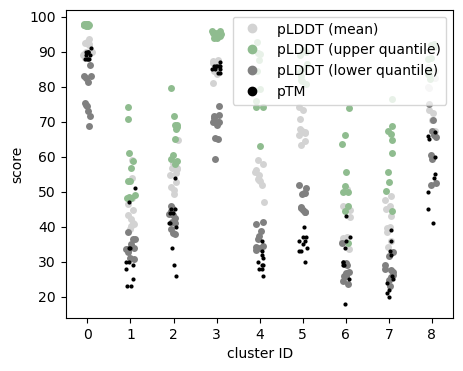

In [61]:
filter_ = filters['level_1_conserved_clusters']

fig, ax = plt.subplots(figsize=(5, 4))

sns.stripplot(figure_df[filter_], x='cluster_id', y='mean_plddt', color='lightgray', ax=ax)
sns.stripplot(figure_df[filter_], x='cluster_id', y='mean_plddt_upper', color='darkseagreen', ax=ax)
sns.stripplot(figure_df[filter_], x='cluster_id', y='mean_plddt_lower', color='gray', ax=ax)
sns.stripplot(figure_df[filter_], x='cluster_id', y='scaled_ptm', color='black', ax=ax, s=3)

handles = [Line2D([], [], marker='o', linestyle='', color='lightgray', label='pLDDT (mean)')]
handles += [Line2D([], [], marker='o', linestyle='', color='darkseagreen', label='pLDDT (upper quantile)')]
handles += [Line2D([], [], marker='o', linestyle='', color='gray', label='pLDDT (lower quantile)')]
handles += [Line2D([], [], marker='o', linestyle='', color='black', label='pTM')]

ax.legend(handles=handles)

ax.set_ylabel('score')
ax.set_xlabel('cluster ID')
ax.set_xticks(ax.get_xticks(), labels=[str(int(i)) for i in ax.get_xticks()])
plt.show()



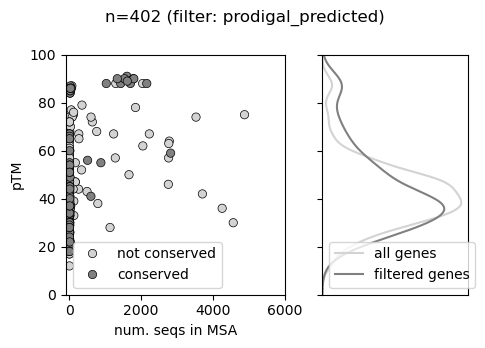

Number of genes with weak structures (< 50 pLDDT): 20
Number of genes with weak structures (< 60 pLDDT): 64
Number of genes with weak structures (< 70 pLDDT): 129


In [75]:
filter_name = 'prodigal_predicted'
filter_ = filters[filter_name]

metric = 'mean_plddt_upper'
metric = 'scaled_ptm'

fig, axes = plt.subplots(figsize=(5, 3.5), ncols=2, width_ratios=[0.6, 0.4], sharey=True)

ax = axes[0]

figure_df['category'] = np.where(figure_df.cluster_id.isin(level_1_conserved_cluster_ids + level_2_conserved_cluster_ids), 'conserved', 'not conserved')

palette = {'conserved':'gray', 'not conserved':'lightgray'}
sns.scatterplot(figure_df[filter_].sort_values('category', ascending=False), x='msa_num_seqs', y=metric, ax=ax, hue='category', palette=palette, edgecolor='black', linewidth=0.5)

y_labels = {'mean_plddt_upper':'pLDDT (upper quantile)', 'scaled_ptm':'pTM'}
ax.set_ylabel(y_labels.get(metric))

ax.set_xlabel('num. seqs in MSA')
ax.set_xticks(ax.get_xticks(), labels=[str(int(i)) for i in ax.get_xticks()])
ax.set_xlim(xmin=-100)
ax.get_legend().set_title('')
fig.suptitle(f'n={filter_.sum()} (filter: {filter_name})')

ax = axes[1]
sns.kdeplot(figure_df, y=metric, color='lightgray', label='all genes')
sns.kdeplot(figure_df[filter_], y=metric, color='gray', label='filtered genes')
# sns.kdeplot(figure_df, y='mean_plddt', color='lightgray', ls='--')
# sns.kdeplot(figure_df[filter_], y='mean_plddt', color='gray', ls='--')
ax.set_xticks([])
ax.set_xlabel('')
ax.legend()
ax.set_ylim(ymin=0, ymax=100)

fig.tight_layout()
plt.show()

print('Number of genes with weak structures (< 50 pLDDT):', (figure_df[filter_].mean_plddt_upper < 50).sum())
print('Number of genes with weak structures (< 60 pLDDT):', (figure_df[filter_].mean_plddt_upper < 60).sum())
print('Number of genes with weak structures (< 70 pLDDT):', (figure_df[filter_].mean_plddt_upper < 70).sum())

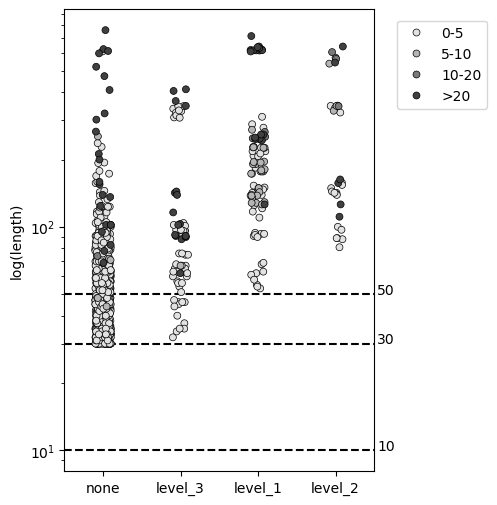

In [77]:
fig, ax = plt.subplots(figsize=(4, 6))

figure_df['has_msa'] = figure_df.msa_num_seqs > 0
figure_df['length'] = figure_df.seq.apply(len)

categories = dict()
categories['level_1'] = figure_df.index.isin([gene_id for gene_ids in level_1_conserved_cluster_gene_ids.values() for gene_id in gene_ids])
categories['level_2'] = figure_df.index.isin([gene_id for gene_ids in level_2_conserved_cluster_gene_ids.values() for gene_id in gene_ids])
categories['level_3'] = figure_df.index.isin([gene_id for gene_ids in level_3_conserved_cluster_gene_ids.values() for gene_id in gene_ids])
categories, conditions = list(zip(*categories.items()))
figure_df['category'] = np.select(conditions, categories, default='none')

# figure_df['msa_num_seqs_bin'] = 'none'
# figure_df.loc[figure_df.has_msa, 'msa_num_seqs_bin'] = pd.qcut(figure_df[figure_df.has_msa].msa_num_seqs, q=10).astype(str)

def get_msa_num_seqs_bin(n):
    if n < 5:
        return '0-5'
    elif n < 10:
        return '5-10'
    elif n < 20:
        return '10-20'
    else:
        return '>20'
    
figure_df['msa_num_seqs_bin'] = figure_df.msa_num_seqs.apply(get_msa_num_seqs_bin)

palette = {True:'darkseagreen', False:'lightgray'}
sns.stripplot(figure_df.sort_values('msa_num_seqs'), x='category', y='length', hue='msa_num_seqs_bin', palette='Grays', legend=True, edgecolor='black', linewidth=0.5)
# sns.stripplot(figure_df[figure_df.has_msa].sort_values('msa_num_seqs'), x='category', y='length', hue='msa_num_seqs_bin', palette='Grays', legend=True, edgecolor='black', linewidth=0.5)
# sns.stripplot(figure_df.sort_values('has_msa'), x='category', y='length', hue='has_msa', palette=palette, legend=False)

ax.legend(bbox_to_anchor=(1.05, 0.99))

for y in [10, 30, 50]:
    ax.axhline(y, ls='--', color='black')
    ax.text(ax.get_xlim()[-1] * 1.01, y, str(y))
ax.set_yscale('log')

ax.set_xlabel('')
ax.set_ylabel('log(length)')
plt.show()

In [65]:
with open(os.path.join(COLABFOLD_DIR, 'plddts.json'), 'r') as f:
    plddts = json.load(f)



# https://www.nature.com/articles/s41587-024-02353-6 It seems like ColabFold still outperforms ESMFold, though if no MSAs are generated, it could be a gray area. 
for 

# Note that "DeepMind has not released the server's exact MSA generation pipeline or databases in the same level of detail as AF2."


SyntaxError: invalid syntax (3052106701.py, line 7)